# 01 - Tracking Demo

This notebook demonstrates the package-facing storm tracking API on the bundled CESM2 example data. It uses a small time subset by default so the notebook stays useful for demo and EDA work.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from stormlab.config import TrackingConfig
from stormlab.tracking import attach_precipitation_events, track_rainstorms

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
OUTPUT_ROOT = REPO_ROOT / "output" / "examples_pipeline"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")

Repo root: c:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab
Data root exists: True


In [3]:
cesm_year_dir = DATA_ROOT / "cesm2" / "bias_corrected_annual_cesm2" / "1251_18" / "2022"
ivt_path = cesm_year_dir / "CESM2_2022_ivt_bs.nc"
prcp_path = cesm_year_dir / "CESM2_2022_prect_bs.nc"

ivt_ds = xr.open_dataset(ivt_path)
prcp_ds = xr.open_dataset(prcp_path)

ivt = ivt_ds["ivt"].data
prcp = prcp_ds["prect"].data

print(ivt_ds)
print(f"IVT shape: {ivt.shape}")
print(f"Precip shape: {prcp.shape}")

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 1460, latitude: 24, longitude: 29)
Coordinates:
  * time       (time) object 12kB 2022-01-01 00:00:00 ... 2022-12-31 18:00:00
  * latitude   (latitude) float64 192B 50.42 49.48 48.53 ... 30.63 29.69 28.74
  * longitude  (longitude) float64 232B -113.8 -112.5 -111.2 ... -80.0 -78.75
Data variables:
    ivt        (time, latitude, longitude) float32 4MB 143.0 170.9 ... 337.3
Attributes:
    description:  CESM2 ivt data over the Mississippi River Basin
IVT shape: (1460, 24, 29)
Precip shape: (1460, 24, 29)


In [4]:
subset = slice(0, 16)
ivt_subset = ivt[subset]
prcp_subset = prcp[subset]

config = TrackingConfig(
    low_threshold=250,
    high_threshold=500,
    morph_radius=1,
    expand_distance=5,
    overlap_ratio=0.2,
    dry_spell_time=0,
)

track_array = track_rainstorms(ivt_subset, config)
attached_prcp = attach_precipitation_events(prcp_subset, track_array)

print(f"Track array shape: {track_array.shape}")
print(f"Tracked event IDs: {np.unique(track_array)[1:20]}")
print(f"Attached precip IDs: {np.unique(attached_prcp)[1:20]}")

Track array shape: (16, 24, 29)
Tracked event IDs: [1]
Attached precip IDs: [1]


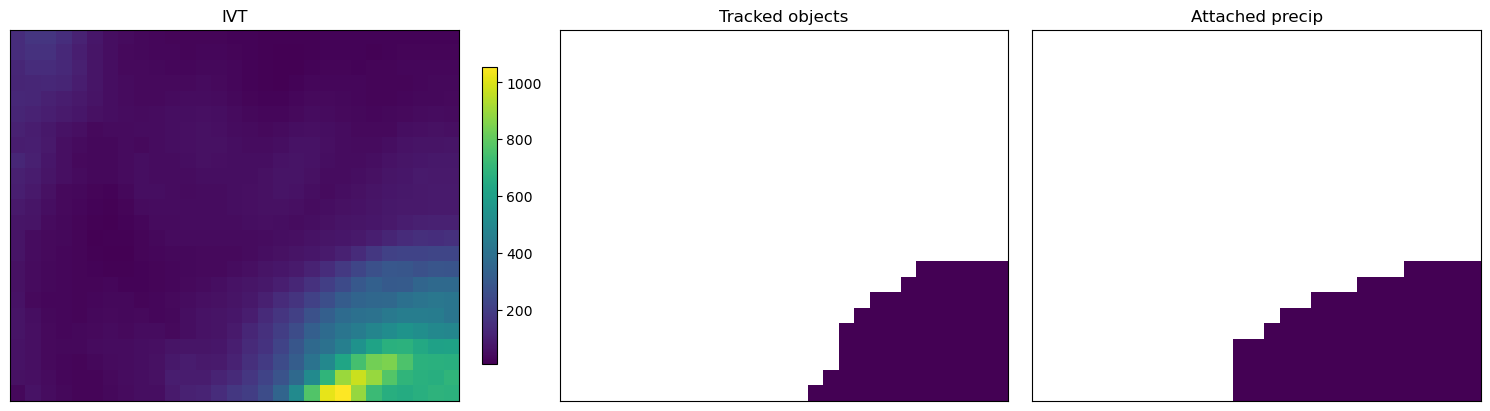

In [5]:
time_index = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(ivt_subset[time_index], origin="upper")
axes[0].set_title("IVT")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

axes[1].imshow(np.ma.masked_where(track_array[time_index] == 0, track_array[time_index]), origin="upper")
axes[1].set_title("Tracked objects")

axes[2].imshow(np.ma.masked_where(attached_prcp[time_index] == 0, attached_prcp[time_index]), origin="upper")
axes[2].set_title("Attached precip")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [ ]:
# Optional save for downstream notebooks or quick inspection.
# np.save(OUTPUT_ROOT / "tracking_subset.npy", track_array)
# np.save(OUTPUT_ROOT / "attached_precip_subset.npy", attached_prcp)